**1. Preprocesamiento: Las imágenes deben estar convertidas a matrices de unos y ceros**

In [1]:
import os
from PIL import Image
import numpy as np

In [ ]:
# Paso 1: Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Paso 2: Definir rutas de entrada y salida
input_folder_neg = "/content/drive/MyDrive/FotosIAproyecto/MejoradasPretodo/ContaminaciónNegativa "
input_folder_pos = "/content/drive/MyDrive/FotosIAproyecto/MejoradasPretodo/ContaminaciónPositiva "
output_folder = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas"

# Crear subcarpetas de salida
output_neg = os.path.join(output_folder, "Negativas")
output_pos = os.path.join(output_folder, "Positivas")
os.makedirs(output_neg, exist_ok=True)
os.makedirs(output_pos, exist_ok=True)

In [ ]:
# Paso 3: Función de procesamiento
def procesar_carpeta(input_folder, output_subfolder, etiqueta):
    for filename in os.listdir(input_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            img = Image.open(os.path.join(input_folder, filename))
            img = img.convert("L")
            img = img.resize((128, 128))
            arr = np.array(img)
            binary_arr = (arr > 250).astype(int)

            # Guardar en la subcarpeta correspondiente
            nombre_salida = f"{etiqueta}_{filename.split('.')[0]}.npy"
            np.save(os.path.join(output_subfolder, nombre_salida), binary_arr)

# Paso 4: Procesar ambas carpetas
procesar_carpeta(input_folder_neg, output_neg, "neg")
procesar_carpeta(input_folder_pos, output_pos, "pos")

print("✅ Procesamiento completado. Los vectores están separados en:")
print(" -", output_neg)
print(" -", output_pos)


✅ Procesamiento completado. Los vectores están separados en:
 - /content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Negativas
 - /content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Positivas


Para ver las matrices del caso de contaminación positiva

In [ ]:
# Opción 1: Para imprimir arrays completos sin truncar
# np.set_printoptions(threshold=np.inf)

# Opción 2: Para imprimir arrays truncados (por defecto, o con un umbral específico, ej. 1000)
# np.set_printoptions(threshold=1000)
# Para restaurar el comportamiento por defecto de truncado de NumPy, simplemente comenta la línea de arriba y reinicia el runtime.

# Carpeta de salida donde están las matrices
#output_neg = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Negativas"
output_pos = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Positivas"

def mostrar_valores(output_folder, etiqueta):
    archivos = sorted([f for f in os.listdir(output_folder) if f.endswith(".npy")])
    for archivo in archivos:
        ruta = os.path.join(output_folder, archivo)
        matriz = np.load(ruta)

        # Mostrar toda la matriz como 0 y 1
        print(f"\nMatriz binaria ({etiqueta}) de {archivo}:")
        print(matriz)   # Imprime la matriz completa

        # Si solo quieres ver una parte (ej. primeras filas)
        # print(matriz[:10,:10])

# Mostrar matrices negativas
#mostrar_valores(output_neg, "neg")

# Mostrar matrices positivas
mostrar_valores(output_pos, "pos")


Matriz binaria (pos) de pos_Documento_10.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (pos) de pos_Documento_11.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (pos) de pos_Documento_12.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (pos) de pos_Documento_13.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (pos) de pos_Documento_14.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (pos) de pos_Documento_15.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]

Para ver las matrices del caso de contaminación negativa

In [ ]:
# Opción 1: Para imprimir arrays completos sin truncar
# np.set_printoptions(threshold=np.inf)

# Opción 2: Para imprimir arrays truncados (por defecto, o con un umbral específico, ej. 1000)
# np.set_printoptions(threshold=1000)
# Para restaurar el comportamiento por defecto de truncado de NumPy, simplemente comenta la línea de arriba y reinicia el runtime.

# Carpeta de salida donde están las matrices
output_neg = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Negativas"
#output_pos = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Positivas"

def mostrar_valores(output_folder, etiqueta):
    archivos = sorted([f for f in os.listdir(output_folder) if f.endswith(".npy")])
    for archivo in archivos:
        ruta = os.path.join(output_folder, archivo)
        matriz = np.load(ruta)

        # Mostrar toda la matriz como 0 y 1
        print(f"\nMatriz binaria ({etiqueta}) de {archivo}:")
        print(matriz)   # Imprime la matriz completa

        # Si solo quieres ver una parte (ej. primeras filas)
        # print(matriz[:10,:10])

# Mostrar matrices negativas
mostrar_valores(output_neg, "neg")

# Mostrar matrices positivas
# mostrar_valores(output_pos, "pos")


Matriz binaria (neg) de neg_Documento_10.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (neg) de neg_Documento_11.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (neg) de neg_Documento_12.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (neg) de neg_Documento_13.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (neg) de neg_Documento_14.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]

Matriz binaria (neg) de neg_Documento_15.npy:
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]

Comprobación de uno de los conjuntos (solo con el fin de ver si hay algo que haya fallado)

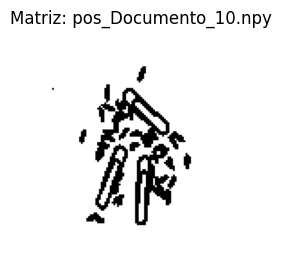

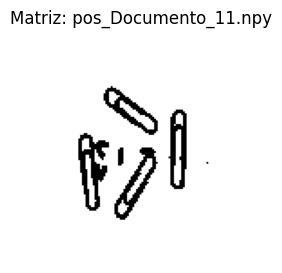

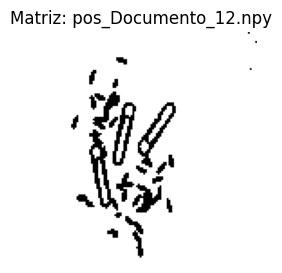

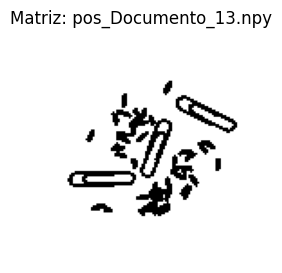

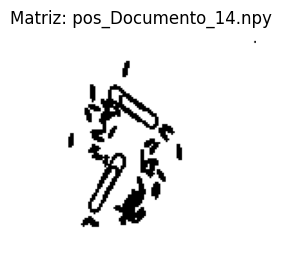

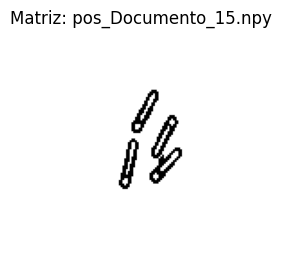

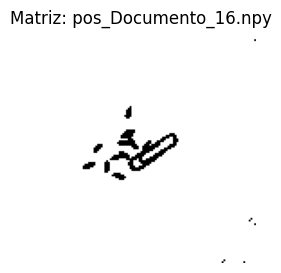

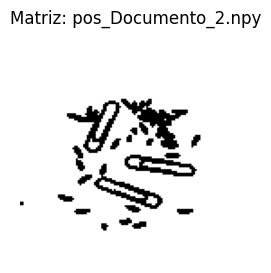

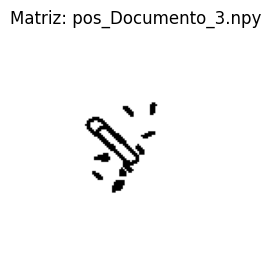

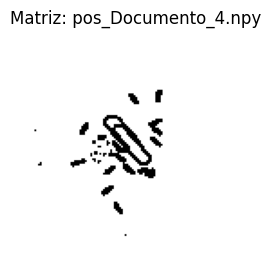

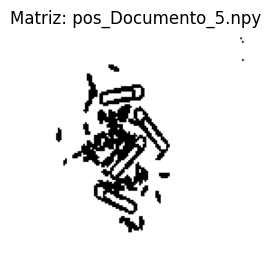

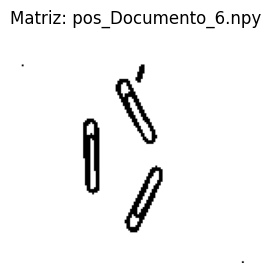

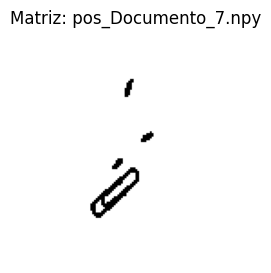

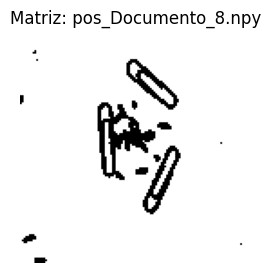

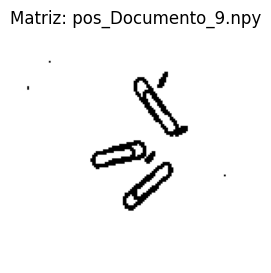

In [ ]:
import matplotlib.pyplot as plt

# Carpeta de salida donde están las matrices positivas
output_pos = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas/Positivas"

# Listar todos los archivos .npy en la carpeta
archivos_pos = sorted([f for f in os.listdir(output_pos) if f.endswith(".npy")])

# Mostrar cada matriz en orden
for archivo in archivos_pos:
    ruta = os.path.join(output_pos, archivo)
    matriz = np.load(ruta)   # Cargar la matriz 128x128

    plt.figure(figsize=(3,3))
    plt.imshow(matriz, cmap="gray")
    plt.title(f"Matriz: {archivo}")
    plt.axis("off")
    plt.show()


**2. Conformar el conjunto de datos para los algoritmos**

In [ ]:
# Rutas de tus carpetas con matrices .npy
ruta_base = "/content/drive/MyDrive/FotosIAproyecto/Imagenes_procesadas"
carpetas = {
    "Positivas": 1,
    "Negativas": 0
}

matriz_final = []

print("Iniciando consolidación de matrices .npy...")

for nombre_carpeta, etiqueta in carpetas.items():
    ruta_especifica = os.path.join(ruta_base, nombre_carpeta)

    if not os.path.exists(ruta_especifica):
        print(f"Error: No se encontró la carpeta en: {ruta_especifica}")
        continue

    archivos = [f for f in os.listdir(ruta_especifica) if f.endswith(".npy")]
    print(f"Encontrados {len(archivos)} archivos en '{nombre_carpeta}'")

    for nombre_archivo in archivos:
        path = os.path.join(ruta_especifica, nombre_archivo)
        matriz = np.load(path)

        # Aplanar la matriz 128x128 → vector de 16384
        vector = matriz.flatten()

        # Añadir etiqueta al final
        vector_fila = np.append(vector, etiqueta)

        matriz_final.append(vector_fila)

# Convertir a array y guardar sin encabezados
dataset = np.array(matriz_final, dtype=int)

salida = "/content/drive/MyDrive/FotosIAproyecto/matriz_final.csv"
np.savetxt(salida, dataset, delimiter=",", fmt='%d')

print("-" * 30)
print(f"✅ Dataset consolidado con forma: {dataset.shape}")
print(f"Archivo guardado en: {salida}")

Iniciando consolidación de matrices .npy...
Encontrados 15 archivos en 'Positivas'
Encontrados 15 archivos en 'Negativas'
------------------------------
✅ Dataset consolidado con forma: (30, 16385)
Archivo guardado en: /content/drive/MyDrive/FotosIAproyecto/matriz_final.csv
